# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
**Machine Learning paradigm:** Supervised learning* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Models**: Deep Learning - 1D CNN
* **Input**:
    *

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Input, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
import pandas as pd
from scipy.signal import resample

I0000 00:00:1779139267.280381  238699 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779139267.357787  238699 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779139268.610462  238699 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
import utils

In [6]:
base_path = 'process_dataset/'
train_path = base_path + 'train'
val_path = base_path + 'val'

In [ ]:
df_weights = pd.read_csv(base_path + 'class_distribution_train.csv')

class_weights = dict(zip(df_weights['Class_ID'], df_weights['Weight']))

print("Class weights are:", class_weights)

total_samples = df_weights['Count'].sum()
batch_size = 32

calculated_steps = total_samples // batch_size

print(f"Total number of samples: {total_samples}")
print(f"Steps per train: {calculated_steps}")

Class weights are: {0: 0.944, 1: 1.7783, 2: 0.5232, 3: 1.445, 4: 1.2905}
Total number of samples: 228213
Steps per train: 7131


# Dataset

## Lad & Lead from Raw Data

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

# Functions

In [6]:
def create_predictions(model, val_data):
    y_pred_probs = model.predict(val_data)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = []

    # Case 1: tf.data.Dataset
    if isinstance(val_data, tf.data.Dataset):
        for _, y_batch_one_hot in val_data:
            y_true.extend(np.argmax(y_batch_one_hot, axis=1))

    # Case 2: Sequence (SleepDataGenerator)
    else:
        for i in range(len(val_data)):
            _, y_batch_one_hot = val_data[i]
            y_true.extend(np.argmax(y_batch_one_hot, axis=1))

    return np.array(y_true), y_pred

In [ ]:
def smooth_predictions(probs, window=5):
    """
    probs: shape (n_samples, n_classes)
    window: odd integer (e.g., 5)
    Returns smoothed probabilities of same shape.
    """
    smoothed = np.zeros_like(probs)
    for c in range(probs.shape[1]):
        smoothed[:, c] = savgol_filter(probs[:, c], window, 2)
    # Clip to [0,1] to avoid numerical issues
    smoothed = np.clip(smoothed, 0, 1)
    # Renormalize to sum to 1
    smoothed = smoothed / smoothed.sum(axis=1, keepdims=True)
    return smoothed

In [ ]:
def model_train_eval(model, train, val, no_epochs, class_weights, early_stopping, reduce_lr, steps_per_epoch=None):
    start_time = time.time()

    model.fit(
        train,
        validation_data=val,
        epochs=no_epochs,
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr],
        steps_per_epoch=steps_per_epoch,
        verbose=1
    )

    end_time = time.time()
    print(f"\nTrain time: {(end_time - start_time) / 60:.2f} minutes.\n")
    y_true, y_pred = create_predictions(model, val)
    utils.evaluate_model(y_true, y_pred)
    return y_true, y_pred

# Models

## Lightweight CNN

* raw data
* 9000x6

E0000 00:00:1778585754.226251   51733 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/40


I0000 00:00:1778585755.252929   51733 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


259/259 ━━━━━━━━━━━━━━━━━━━━ 206s 790ms/step - accuracy: 0.3127 - loss: 1.4591 - val_accuracy: 0.3810 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 2/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 201s 776ms/step - accuracy: 0.4324 - loss: 1.2770 - val_accuracy: 0.4554 - val_loss: 1.2577 - learning_rate: 0.0010
Epoch 3/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 210s 814ms/step - accuracy: 0.5021 - loss: 1.1383 - val_accuracy: 0.5379 - val_loss: 1.0967 - learning_rate: 0.0010
Epoch 4/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 213s 827ms/step - accuracy: 0.5195 - loss: 1.1082 - val_accuracy: 0.4804 - val_loss: 1.1633 - learning_rate: 0.0010
Epoch 5/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 213s 823ms/step - accuracy: 0.5463 - loss: 1.0578 - val_accuracy: 0.5306 - val_loss: 1.0887 - learning_rate: 0.0010
Epoch 6/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 217s 837ms/step - accuracy: 0.5571 - loss: 1.0548 - val_accuracy: 0.6081 - val_loss: 1.0090 - learning_rate: 0.0010
Epoch 7/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 211s 817ms/step - accuracy: 0.5924 

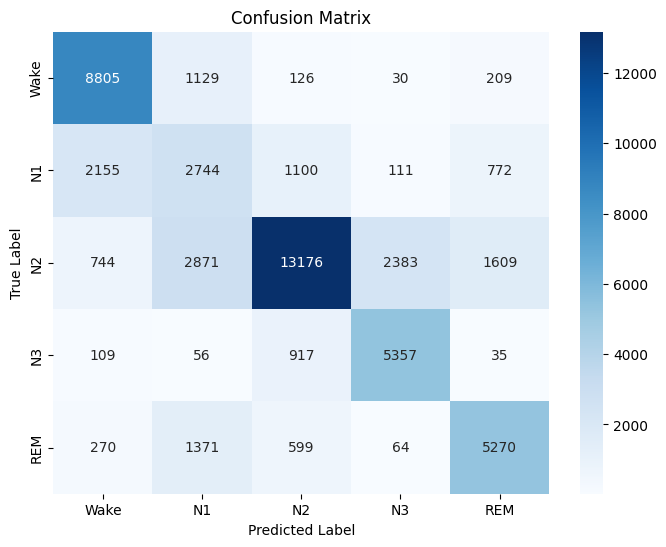

Cohen Kappa: 0.5839



In [ ]:
def build_lightweight_cnn(input_shape=(9000, 6)):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(16, 50, strides=4, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),
        Conv1D(32, 15, strides=2, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),
        Conv1D(64, 7, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_lightweight_cnn(input_shape=(9000, 6))

early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

y_true, y_pred = model_train_eval(model, train_gen, val_gen, 40, class_weights, early_stopping, reduce_lr)

## Raw‑Signal CNN

* best model
* 9000x6

Epoch 1/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 222s 853ms/step - accuracy: 0.2484 - loss: 1.5544 - val_accuracy: 0.2985 - val_loss: 1.4613 - learning_rate: 0.0010
Epoch 2/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 216s 834ms/step - accuracy: 0.3902 - loss: 1.3213 - val_accuracy: 0.4613 - val_loss: 1.2659 - learning_rate: 0.0010
Epoch 3/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 223s 865ms/step - accuracy: 0.4684 - loss: 1.2167 - val_accuracy: 0.5285 - val_loss: 1.2994 - learning_rate: 0.0010
Epoch 4/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 215s 830ms/step - accuracy: 0.4930 - loss: 1.1663 - val_accuracy: 0.5326 - val_loss: 1.1117 - learning_rate: 0.0010
Epoch 5/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 215s 832ms/step - accuracy: 0.5363 - loss: 1.1119 - val_accuracy: 0.5241 - val_loss: 1.1670 - learning_rate: 0.0010
Epoch 6/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 221s 856ms/step - accuracy: 0.5402 - loss: 1.1029 - val_accuracy: 0.4990 - val_loss: 1.1823 - learning_rate: 0.0010
Epoch 7/40
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy

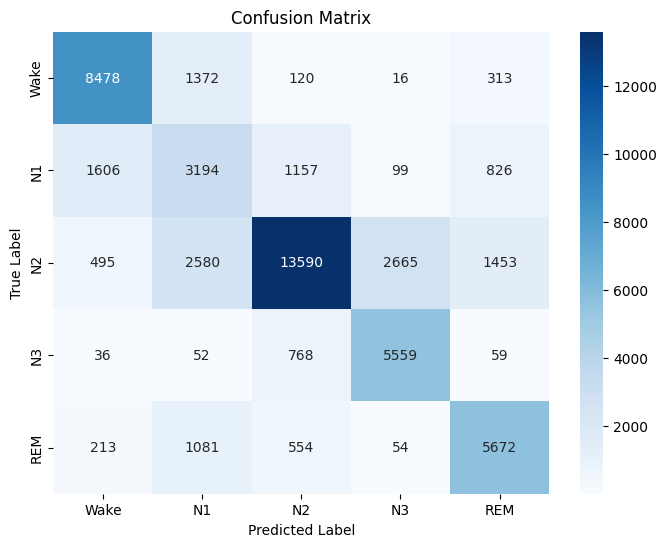

Cohen Kappa: 0.6125



In [14]:
def build_medium_cnn(input_shape=(9000, 2)):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(32, 50, strides=4, activation='relu', padding='same'),
        MaxPooling1D(4),
        Conv1D(64, 15, strides=2, activation='relu', padding='same'),
        MaxPooling1D(4),
        Conv1D(128, 7, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(256, 5, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_medium_cnn(input_shape=(9000, 6))

early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

y_true, y_pred = model_train_eval(model, train_gen, val_gen, 40, class_weights, early_stopping, reduce_lr)